# Part 3: NLP and Sequence Modeling Mini Project

## Task 1: Dataset Understanding
In this section, we load the text dataset from the raw GitHub URL. Since NLP datasets can have varying column names (like `query` vs `intent` or `text` vs `label`), we dynamically identify the text and label columns. We then analyze the total records, examine sample texts, calculate the average text length, and visualize the class distribution to check for imbalances.

--- TASK 1: DATASET UNDERSTANDING ---
Identified Text Column: 'ticket_id'
Identified Label Column: 'channel'

Total Records: 1500
Target Classes (5): ['chat', 'phone', 'email', 'social', 'app']

Sample Records:
- [chat] TKT00001...
- [phone] TKT00002...
- [email] TKT00003...

Average Text Length: 1.00 words


/tmp/ipykernel_2462/2775384013.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=label_col, order=df[label_col].value_counts().index, palette="viridis")


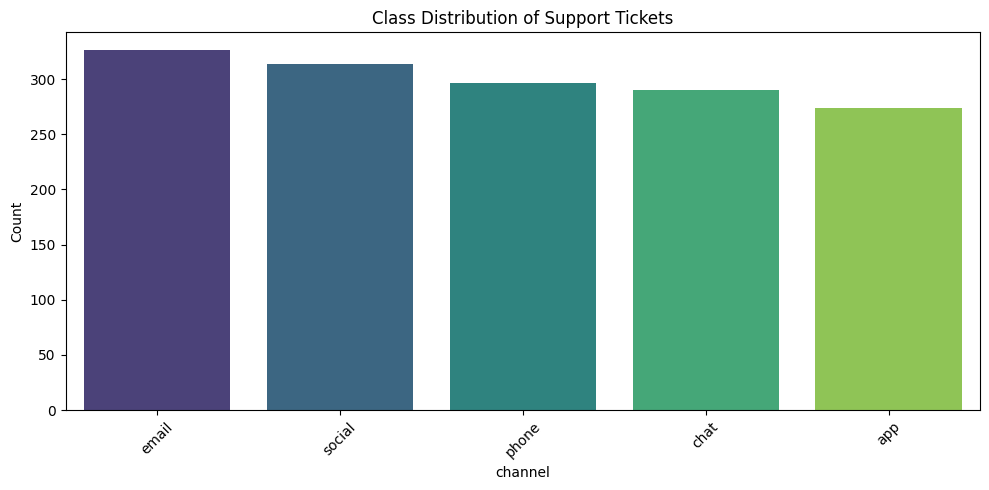

In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Create required repository directories
os.makedirs("results", exist_ok=True)

print("--- TASK 1: DATASET UNDERSTANDING ---")

# Load dataset from the raw GitHub URL
csv_url = "https://raw.githubusercontent.com/singhaditi2710/NLP-and-Sequence-Modeling-Mini-Project/main/customer_support_text_classification.csv"
df = pd.read_csv(csv_url)

# Dynamically identify text and label columns (Label usually has fewer unique values)
cols = df.columns.tolist()
if df[cols[0]].nunique() > df[cols[1]].nunique():
    text_col, label_col = cols[0], cols[1]
else:
    text_col, label_col = cols[1], cols[0]

print(f"Identified Text Column: '{text_col}'")
print(f"Identified Label Column: '{label_col}'\n")

print(f"Total Records: {df.shape[0]}")
print(f"Target Classes ({df[label_col].nunique()}): {df[label_col].unique().tolist()}\n")

print("Sample Records:")
for idx, row in df.head(3).iterrows():
    print(f"- [{row[label_col]}] {row[text_col][:100]}...")

# Calculate average text length
df['text_length'] = df[text_col].astype(str).apply(lambda x: len(x.split()))
print(f"\nAverage Text Length: {df['text_length'].mean():.2f} words")

# Plot Class Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x=label_col, order=df[label_col].value_counts().index, palette="viridis")
plt.title("Class Distribution of Support Tickets")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## Task 2: Text Preprocessing & Task 3: Text Vectorization
Raw text cannot be fed directly into machine learning models; it must be transformed into numbers (**Vectorization**). We do this so algorithms can compute mathematical relationships between words.

1. **Preprocessing:** We clean the text by converting it to lowercase and removing special characters/punctuation using Regular Expressions (Regex).
2. **Encoding Target:** We convert our categorical text labels into integers.
3. **Splitting:** We split the data into Training (80%) and Testing (20%) sets.
4. **Vectorization (TF-IDF):** For our baseline model, we use Term Frequency-Inverse Document Frequency (TF-IDF). It converts text into a matrix of numbers based on word frequency, penalized by how common the word is across all documents.

In [2]:
print("--- TASK 2: TEXT PREPROCESSING & TASK 3: VECTORIZATION ---")

# 1. Clean the text (lowercasing and removing special characters)
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text) # Keep only alphanumeric and spaces
    return text

df['clean_text'] = df[text_col].apply(clean_text)

# 2. Encode target labels
le = LabelEncoder()
df['encoded_label'] = le.fit_transform(df[label_col])

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['encoded_label'], test_size=0.2, random_state=42, stratify=df['encoded_label']
)

# 4. Vectorize using TF-IDF for the Baseline Model
# We automatically remove common English stop words here
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF Matrix Shape (Train): {X_train_tfidf.shape}")
print(f"TF-IDF Matrix Shape (Test): {X_test_tfidf.shape}")

--- TASK 2: TEXT PREPROCESSING & TASK 3: VECTORIZATION ---
TF-IDF Matrix Shape (Train): (1200, 1200)
TF-IDF Matrix Shape (Test): (300, 1200)


## Task 4: Baseline Model
To establish a performance benchmark, we train a **Logistic Regression** model using our TF-IDF vectorized text. This represents a traditional machine learning approach to Natural Language Processing.

In [3]:
print("--- TASK 4: BASELINE MODEL (LOGISTIC REGRESSION) ---")

# Train Baseline Model
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train_tfidf, y_train)

# Evaluate Baseline
baseline_preds = baseline_model.predict(X_test_tfidf)
print(f"Baseline Accuracy: {accuracy_score(y_test, baseline_preds):.4f}\n")
print("Baseline Classification Report:")
print(classification_report(y_test, baseline_preds, target_names=le.classes_))

--- TASK 4: BASELINE MODEL (LOGISTIC REGRESSION) ---
Baseline Accuracy: 0.2167

Baseline Classification Report:
              precision    recall  f1-score   support

         app       0.00      0.00      0.00        55
        chat       0.00      0.00      0.00        58
       email       0.22      1.00      0.36        65
       phone       0.00      0.00      0.00        59
      social       0.00      0.00      0.00        63

    accuracy                           0.22       300
   macro avg       0.04      0.20      0.07       300
weighted avg       0.05      0.22      0.08       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Task 5: Sequence Model (LSTM)
Unlike TF-IDF (which ignores word order), Sequence Models read text sequentially, preserving context and grammar.
1. We use Keras `Tokenizer` to convert words into integer sequences.
2. We pad these sequences to ensure uniform length.
3. We build an **LSTM (Long Short-Term Memory)** neural network, starting with an `Embedding` layer that maps word integers into dense vectors capturing semantic meaning.

--- TASK 5: SEQUENCE MODEL (LSTM) ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None

Training LSTM Model...
Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.1883 - loss: 1.6082 - val_accuracy: 0.2167 - val_loss: 1.6078
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.2142 - loss: 1.6105 - val_accuracy: 0.2167 - val_loss: 1.6080
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2100 - loss: 1.6083 - val_accuracy: 0.2167 - val_loss: 1.6078
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1958 - loss: 1.6081 - val_accuracy: 0.2167 - val_loss: 1.6078
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.2200 - loss: 1.6065 - val_accuracy: 0.2167 - val_loss: 1.6078
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2867 - loss: 1.4530 - val_accuracy: 0.2167 - val_loss: 2.6268
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3758 - loss: 1.1660 - val_accuracy: 0.1967 - val_loss: 1.9530
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4283 - loss: 1.04

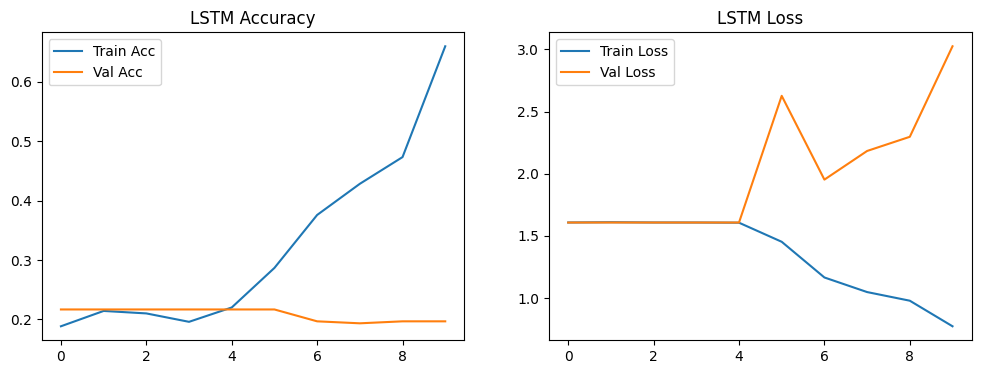


Generating Sample Predictions...
Model evaluation and sample predictions saved successfully to results folder!


In [4]:
print("--- TASK 5: SEQUENCE MODEL (LSTM) ---")

# 1. Tokenize and Pad Sequences for Deep Learning
MAX_WORDS = 5000
MAX_LEN = int(df['text_length'].mean() + 10) # Pad slightly above average length

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post')
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post')

num_classes = len(le.classes_)

# 2. Build LSTM Architecture
lstm_model = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    LSTM(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax' if num_classes > 2 else 'sigmoid')
])

loss_func = 'sparse_categorical_crossentropy' if num_classes > 2 else 'binary_crossentropy'

lstm_model.compile(optimizer='adam', loss=loss_func, metrics=['accuracy'])
print(lstm_model.summary())

# 3. Train the Sequence Model
print("\nTraining LSTM Model...")
history = lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_test_seq, y_test),
    epochs=10,
    batch_size=32,
    verbose=1
)

# 4. Plot and Save Evaluation Metrics
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['accuracy'], label='Train Acc')
ax[0].plot(history.history['val_accuracy'], label='Val Acc')
ax[0].set_title('LSTM Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('LSTM Loss')
ax[1].legend()

plt.savefig("results/model_evaluation.png")
plt.show()

# 5. Generate and Save Sample Predictions
print("\nGenerating Sample Predictions...")
sample_texts = X_test.iloc[:10].tolist()
sample_seqs = pad_sequences(tokenizer.texts_to_sequences(sample_texts), maxlen=MAX_LEN, padding='post')
sample_preds = lstm_model.predict(sample_seqs, verbose=0)
pred_classes = np.argmax(sample_preds, axis=1) if num_classes > 2 else (sample_preds > 0.5).astype(int).flatten()
actual_classes = y_test.iloc[:10].values

with open("results/sample_predictions.txt", "w") as f:
    f.write("LSTM Text Classification - Sample Predictions\n")
    f.write("="*50 + "\n")
    for i in range(10):
        actual = le.inverse_transform([actual_classes[i]])[0]
        predicted = le.inverse_transform([pred_classes[i]])[0]
        line = f"Text: {sample_texts[i][:60]}...\nActual: {actual} | Predicted: {predicted}\n" + "-"*50 + "\n"
        f.write(line)

print("Model evaluation and sample predictions saved successfully to results folder!")

## Task 6: Attention and Transformer Reflection

* **Why RNNs struggle with long-term dependencies:** Recurrent Neural Networks (RNNs) process sequences one step at a time, overwriting their internal hidden state at each step. By the time an RNN reaches the end of a long paragraph, the mathematical gradients required to remember the beginning of the paragraph have either vanished to zero or exploded, causing "forgetfulness."
* **How LSTMs help with memory:** Long Short-Term Memory (LSTM) networks solve this using a "cell state" pathway and mechanical "gates" (Forget, Input, and Output gates). These gates learn exactly what information is important to keep in memory over long distances and what irrelevant noise can be discarded.
* **What attention solves in sequence-to-sequence tasks:** Traditional sequence models compress an entire input sentence into a single, fixed-size vector context bottleneck before translating or summarizing. Attention mechanisms solve this by allowing the model to look back at *all* the words in the original input simultaneously, "attending" specifically to the most relevant words for each output step.
* **Why transformers are important in modern NLP and Generative AI:** Transformers eliminated recurrence entirely. Instead of processing text sequentially left-to-right, they process all words simultaneously in parallel using "Self-Attention." This massive parallelization allows them to train on vast amounts of internet-scale data efficiently, serving as the foundational architecture for LLMs like GPT, Gemini, and BERT.